In [102]:
from matplotlib import pyplot as plt
from scipy.stats import norm

import numpy as np

rng = np.random.default_rng(13)

# Gibbs Sampler

## The Gibbs Sampling Problem

The Gibbs sampler is a type of Markov Chain Monte Carlo algorithm for sampling from a specified multivariate distribution when sampling directly from
the joint distribution is difficult, but access the conditional distribution is possible. The set up is as follows, given a multivariate parameter $\theta = (\theta_1, \ldots, \theta_d)$, let $\pi(\theta | y) = \pi(\theta_1, \ldots, \theta_d | y)$ be the joint distribution (which we do not have access to directly for sampling), and the conditionals are
$$
    p(\theta_j \mid \theta_{-j}, y), \qquad j = 1,\ldots, d\;,
$$
where $\theta_{j-1}$ represents all components of $\theta$ except for $\theta_j$.

A Gibbs sampler alternates between draws of these $d$ conditional distributions. More specifically, at each iteration of the Gibbs sampler, an ordering is established of the $d$ parameters within $\theta$, and $\theta_{j}^t$ is sampled from the conditional distribution given all the other components at their current values:
$$
    \theta_j^t \sim p(\theta_j \mid \theta_{-j}^{t-1}, y)
$$
where $\theta_{-j}^{t-1}$ is all components of $\theta$, except for $\theta_j$ *at their current value*:
$$
    \theta_{-j}^{t-1} = (\theta_1^t, \theta_2^t, \ldots, \theta_{j-1}^t, \theta_{j+1}^{t-1}, \ldots, \theta_d^{t-1})\;.
$$
From the ordering, we see through the notation that the first $j$ components have been updated hence we use their current iteration-$t$ value, while the remaining
components have yet to be updated in which case we use the current $t-1$-iteration information. 

## Why does Gibbs Preserve the Target 

To simplify notation, assume we can break theta into two sub-vectors $\theta = (\theta_1, \theta_2) \sim \pi(\theta_1, \theta_2 | y)$, and assume the Gibbs state has said target distribution. Then the Gibbs sampler iteration will make draws from both of the following conditional distributions
$$
    p(\theta_1 | \theta_2, y)\;,
$$
and
$$
p(\theta_2 | \theta_1, y)\;.
$$
Consider updating $\theta_1$: we retain $\theta_2 \sim p(\theta_2 | y)$ then draw $\theta_1^{new}$ from $p(\theta_1 | \theta_2, y)$. The resulting joint distribution of $(\theta_1^{new}, \theta_2)$ is exactly 
$$
p(\theta_1 | \theta_2, y)\, p(\theta_2|y) = \pi(\theta_1, \theta_2 | y)\;,
$$
by the definition of the joint density. So the target distribution is preserved. Likewise, the same procedure can be conjured for $\theta_2$. Since we just saw that the pair $(\theta_1^{new}, \theta_2) \sim \pi(\theta_1, \theta_2, y)$, we have the marginal $\theta_1^{new} \sim p(\theta_1|y)$. Retaining $\theta_1^{new}$, we draw $\theta_2^{new} \sim p(\theta_2 | \theta_1^{new}, y)$. The resulting joint density of $(\theta_1^{new}, \theta_2^{new})$ is:
$$
p(\theta_2 | \theta_1^{new}, y) p(\theta_1 | y) = \pi(\theta_1, \theta_2, y)
$$
which shows that the target joint density is preserved after a Gibbs iteration.
    

## Connection to Metropolis Hastings

Gibbs sampling is known to be a special case of the Metropolis Hastings algorithm (See `metropolis_hastings.ipynb`). To see this, we recall that for Metropolis Hastings, we are trying to sample from a target distribution $\pi$, using a proposal distribution $q$. Treat the proposal distribution (which we are able to sample from) as the conditional distribution e.g. $q(\theta_1^{new} | \theta_1, \theta_2, y) = p(\theta_1 | \theta_2, y)$. Then the Metropolis Hastings acceptance ratio becomes:
$$
    r_{MH} = \frac{\pi(\theta_1^{new}, \theta_2 | y) q(\theta_1 | \theta_1^{new}, \theta_2, y)}{\pi(\theta_1, \theta_2 | y) q(\theta_1^{new} | \theta_1, \theta_2, y)} = \frac{\pi(\theta_1^{new}, \theta_2 | y) p(\theta_1 | \theta_2, y)}{\pi(\theta_1, \theta_2 | y) p(\theta_1^{new}|\theta_2, y)}
$$
multiplying and dividing by $p(\theta_2 | y)$ we have
$$
    r_{MH} = \frac{\pi(\theta_1^{new}, \theta_2 | y) \cdot p(\theta_1 | \theta_2, y) p(\theta_2 | y)}{\pi(\theta_1, \theta_2 | y) \cdot p(\theta_1^{new}|\theta_2, y) p(\theta_2 | y)} = \frac{\pi(\theta_1^{new}, \theta_2 | y) \pi(\theta_1, \theta_2 | y)}{\pi(\theta_1, \theta_2 | y) \pi(\theta_1^{new}, \theta_2 | y)} = 1\;.
$$
What this shows us is that the Gibbs iteration has a Metropolis-Hastings acceptance ratio of 1, which is equivalent to an acceptance probability of 1. What this tells us is: Every Gibbs update is retained in the chain, but that does not mean the update are independent as there is dependence of the parameters to previous states through the use of the conditional density as the proposal. 

## Simulation Example: Correlated Bivariate Normal Distribution


### Target Distribution: Correlated Bivariate Gaussian

Consider the general (correlated) bivariate normal distribution:
$$
    \begin{pmatrix}
        \theta_1 \\
        \theta_2
    \end{pmatrix} \mid y \sim N\left( \begin{pmatrix} y_1 \\ y_2 \end{pmatrix}, 
    \begin{pmatrix} \sigma^2_{1} & \rho \sigma_1 \sigma_2 \\ \rho\sigma_1\sigma_2 & \sigma_2^2 \end{pmatrix} \right)
$$
which is the posterior distribution of a single observation $(y_1, y_2)$ from a bivariate normal distribution with mean
$\theta = (\theta_1, \theta_2)$ and covariance matrix $$ \Sigma = \begin{pmatrix} \sigma^2_{1} & \rho \sigma_1 \sigma_2 \\ \rho\sigma_1\sigma_2 & \sigma_2^2 \end{pmatrix},$$
with a uniform prior on $\theta$. 

Our target distribution is such that $(y_1, y_2) = 0$, $\sigma_1 = \sigma_2 = 1$, and $\rho = 0.9$. I derived on paper the following marginal densities:
$$
    \theta_1 \mid \theta_2, y \sim N(0.9\,\theta_2, 0.19),
$$
and
$$
    \theta_2 \mid \theta_1, y \sim N(0.9\,\theta_1, 0.19).
$$
Extracting, we have that
$$
    E[\theta_1 \mid \theta_2, y] = 0.9 \cdot \theta_2, \qquad \operatorname{Var}(\theta_1 \mid \theta_2, y) = (1-\rho^2) = 0.19,
$$
and
$$
    E[\theta_2 \mid \theta_1, y] = 0.9 \cdot \theta_1, \qquad \operatorname{Var}(\theta_2 \mid \theta_1, y) = (1-\rho^2) = 0.19.
$$

We now translate this to code:

In [14]:
def theta_cond_params(param, rho=0.9):
    # Function that returns the expectation and standard deviation of \theta | param, y
    return (rho * param, np.sqrt(1-rho**2))

# tests
# 1. zero correlation should yield N(0,1) for theta_1
param = 2.5 # redudant in this test case
rho = 0
exp_t1, std_t1 = theta_cond_params(param, rho)
print("TEST 1: No Correlation")
print("For rho = 0, we have no correlation and should expect a mean = 0.0, and std = 1.0")
print("OUTPUT:")
print(f"Expected value: {exp_t1: .1f}, Std: {std_t1: .1f}")
if ((exp_t1 == 0.0) & (std_t1 == 1.0)):
    print("TEST PASSED")

# 2. positive or negative corelation should shift the mean respectively in the expected direction
#       standard deviation should decrease as |rho| increases
rho1 = 0.5
rho2 = -0.5
rho3 = 0.99
param = 2.5

exp_t1_r1, std_t1_r1 = theta_cond_params(param, rho1)
exp_t1_r2, std_t1_r2 = theta_cond_params(param, rho2)
exp_t1_r3, std_t1_r3 = theta_cond_params(param, rho3)

print("\nTEST 2: Varying Correlation")
print("Should expect positive rho to shift right from 0.0, negative rho to shift left from 0.0, and rho large -> small std")
print("OUTPUT:")
print(f"Rho = 0.5, Expected value: {exp_t1_r1: .1f}, Std: {std_t1_r1: .1f}")
print(f"Rho = -0.5, Expected value: {exp_t1_r2: .1f}, Std: {std_t1_r2: .1f}")
print(f"Rho = 0.99, Expected value: {exp_t1_r3: .1f}, Std: {std_t1_r3: .1f}")
if ((exp_t1_r1 > 0.0) & (exp_t1_r2 < 0.0) & (std_t1_r3 < std_t1_r1)):
    print("TEST PASSED")



TEST 1: No Correlation
For rho = 0, we have no correlation and should expect a mean = 0.0, and std = 1.0
OUTPUT:
Expected value:  0.0, Std:  1.0
TEST PASSED

TEST 2: Varying Correlation
Should expect positive rho to shift right from 0.0, negative rho to shift left from 0.0, and rho large -> small std
OUTPUT:
Rho = 0.5, Expected value:  1.2, Std:  0.9
Rho = -0.5, Expected value: -1.2, Std:  0.9
Rho = 0.99, Expected value:  2.5, Std:  0.1
TEST PASSED


### Implementing the Conditional Draws

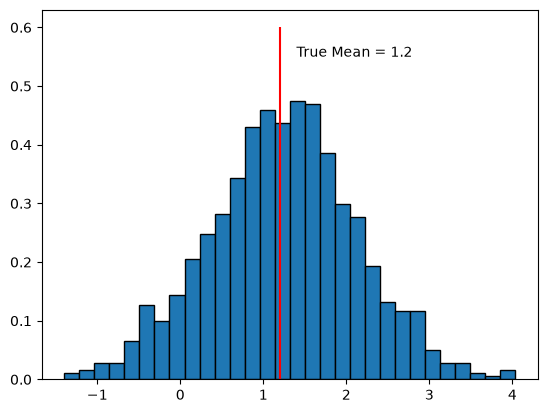

In [30]:
def sample_theta(cond_param, rng, rho=0.9, size=1):
    # function that returns the conditional mean in our scenario
    # supply the parameter you are conditioning on
    mean, std = theta_cond_params(cond_param, rho)
    return rng.normal(mean, std, size)

# Test, we fix the conditional parameter = 2.5, and rho=0.5 draw 1000 samples then plot
# Based on the output above, we should expect the data to have the most mass around 1.2
cond_samples = sample_theta(2.5, rng, rho=0.5, size=1000)

plt.hist(
    cond_samples,
    bins=30,
    density=True,
    edgecolor="black",
)
plt.vlines([1.2], ymin=0, ymax=0.6, colors="red")
plt.text(1.4, 0.55, "True Mean = 1.2")
plt.show()



### Implementing the Gibbs Sampler

In [55]:
def gibbs_bivariate_normal(
        initial_state,
        n_iter,
        mean,
        std, 
        rho,
        rng,
):
    
    t1, t2 = initial_state
    samples = np.zeros((n_iter, 2))
    samples[0] = initial_state

    for i in range(1, n_iter):
        ## Update t1
        # draw t1 from p(t1 | t2, y)
        t1 = sample_theta(t2, rng, rho, size=None)

        ## Update t2
        # draw t2 from p(t2 | t1_new, y)
        t2 = sample_theta(t1, rng, rho, size=None)

        # Store sample
        samples[i] = np.array([t1, t2])

    return samples


### Running Single Chain Simulation

In [ ]:
# Test run: 1 chain, rho = 0.9, initial state (t1, t2) = (-4,4)
rho = 0.9
init_state = np.array([-4, 4])

c1 = gibbs_bivariate_normal(init_state, 10000, 0.0, 1.0, rho, rng)
c1_burn = c1[1000:,]
c1_burn.shape # should be (9000, 2) given input of 10000

(9000, 2)

#### Diagnostics

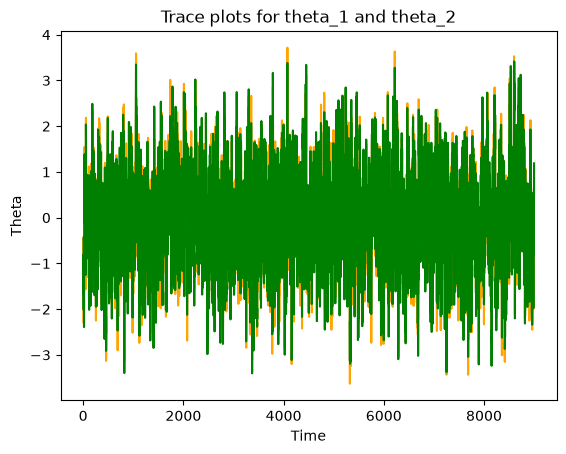

In [84]:
# TRACE PLOTS
theta_1_samples = c1_burn[:, 0]
theta_2_samples = c1_burn[:, 1]
time_grid = np.arange(len(c1_burn))

plt.plot(
    time_grid,
    theta_1_samples,
    label="Chain 1: theta_1",
    color="orange"
)
plt.plot(
    time_grid,
    theta_2_samples,
    label="Chain 1: theta_2",
    color="green"
)
plt.title("Trace plots for theta_1 and theta_2")
plt.xlabel("Time")
plt.ylabel("Theta")
plt.show()

The trace plots show that the conditional distributions for $\theta_1$ and $\theta_2$ are converging about a mean of $0.0$, are mixing well (fast exploration / rapid jumps as t increases), and no obvious autocorrelation.

The following plots the marginal histograms of $\theta_1$ and $\theta_2$ with their true density overlayed, as well as scatter plot of $(\theta_1, \theta_2)$ pairs to see if we are getting a bivariate normal centred around $(0,0)$ with a strong positive correlation (moving up to the right as $\theta_1$ and $\theta_2$ increase together).

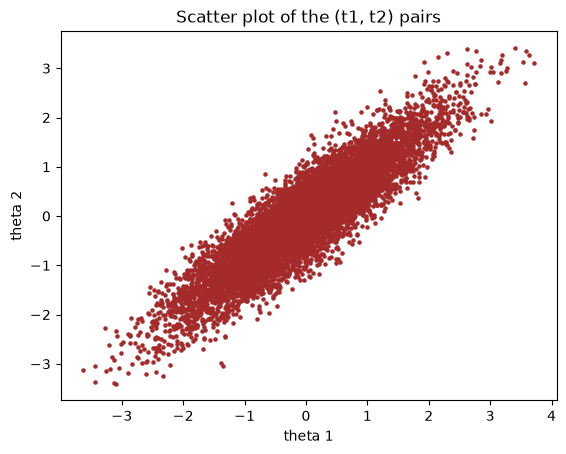

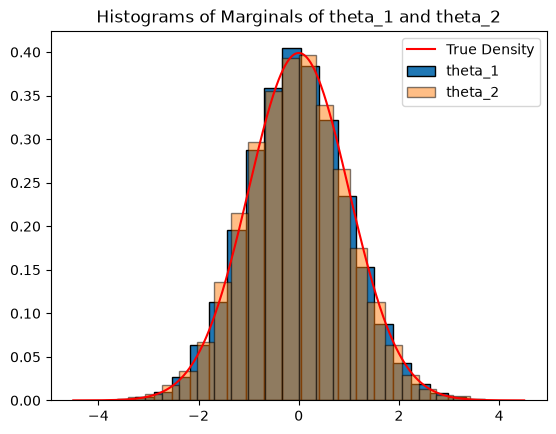

In [105]:
# SCATTER PLOT
plt.scatter(
    theta_1_samples,
    theta_2_samples,
    s=5,
    color="brown"
)
plt.title("Scatter plot of the (t1, t2) pairs")
plt.xlabel("theta 1")
plt.ylabel("theta 2")
plt.show()

# TRUTH
x_grid = np.linspace(-4.5,4.5,1000)
true_vals = norm.pdf(x_grid, 0.0, 1.0) # both theta_1 and theta_2 
plt.plot(
    x_grid,
    true_vals,
    color="red",
    label="True Density"
)
# EMPIRICAL
plt.hist(
    theta_1_samples,
    bins=20,
    density=True,
    edgecolor='black',
    label='theta_1',
)
plt.hist(
    theta_2_samples,
    bins=20,
    density=True,
    edgecolor='black',
    alpha=0.5,
    label='theta_2',
)
plt.title("Histograms of Marginals of theta_1 and theta_2")
plt.legend()
plt.show()

#### Comparing Empirical Mean and Variance to the Truth/Target

In [106]:
# empirical mean and variance of the marginals of theta_1 and theta_2
emp_mean_t1 = np.mean(theta_1_samples)
emp_mean_t2 = np.mean(theta_2_samples)

emp_var_t1 = np.var(theta_1_samples, ddof=1)
emp_var_t2 = np.var(theta_2_samples, ddof=1)

t1_t2_correlation = np.corrcoef(theta_1_samples, theta_2_samples)[0, 1] # extract first off diagonal

print("==EMPIRICAL RESULT==")
print(f"THETA 1 (marginal): Mean = {emp_mean_t1: .4f},   Var = {emp_var_t1: .4f}")
print(f"THETA 2 (marginal): Mean = {emp_mean_t2: .4f},   Var = {emp_var_t2: .4f}")
print(f"Empirical Correlation Coefficient (rho) = {t1_t2_correlation: .4f}")
print("=========")
print("\n==TRUTH==")
print(f"THETA 1 (marginal): Mean = {0.0},   Var = {1.0}")
print(f"THETA 2 (marginal): Mean = {0.0},   Var = {1.0}")
print(f"True Correlation Coefficient (rho) = {rho}")
print("=========")

==EMPIRICAL RESULT==
THETA 1 (marginal): Mean = -0.0424,   Var =  0.9896
THETA 2 (marginal): Mean = -0.0404,   Var =  0.9887
Empirical Correlation Coefficient (rho) =  0.8995

==TRUTH==
THETA 1 (marginal): Mean = 0.0,   Var = 1.0
THETA 2 (marginal): Mean = 0.0,   Var = 1.0
True Correlation Coefficient (rho) = 0.9
